Student Name: Pratik Shrestha
Student ID: 2413998
Task 3

In [2]:
!pip install --upgrade pip -q
!pip install wordcloud gradio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.4 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, time
from collections import Counter
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

MODEL_SAVE = '/content/drive/MyDrive/6CS012_NLP/models/'
import os; os.makedirs(MODEL_SAVE, exist_ok=True)
print("Ready!")

Mounted at /content/drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Ready!


In [5]:
df = pd.read_csv('/content/drive/MyDrive/6CS012_NLP/datasets/Hotel Review Dataset/Hotel_Reviews.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head(3))
print("\nRating distribution:")
print(df['Rating'].value_counts().sort_index())
print("\nNull values:", df.isnull().sum())

Shape: (20491, 2)
Columns: ['Review', 'Rating']
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Null values: Review    0
Rating    0
dtype: int64


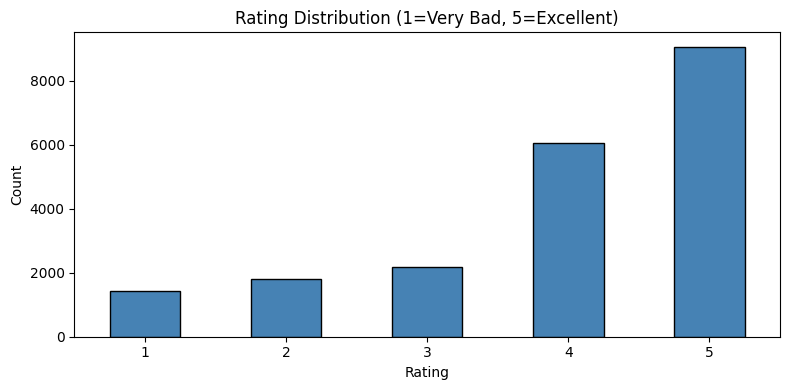

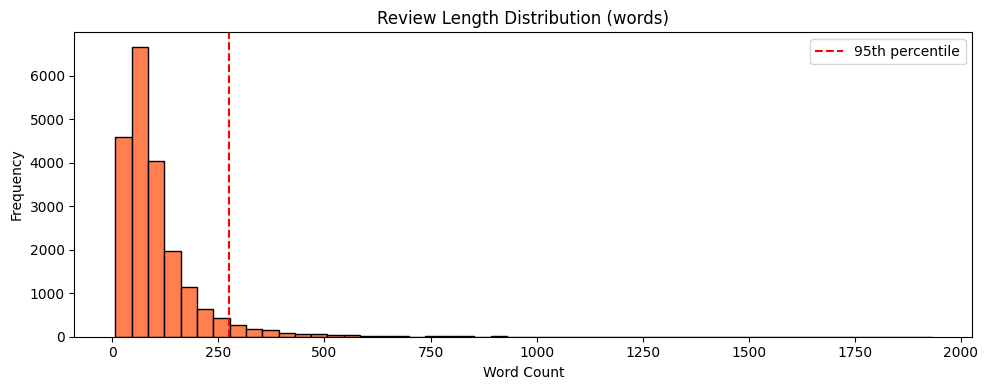

Median length: 77 | 95th percentile: 275


In [6]:
# Class distribution
plt.figure(figsize=(8, 4))
df['Rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution (1=Very Bad, 5=Excellent)')
plt.xlabel('Rating'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Review length distribution
df['review_length'] = df['Review'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 4))
plt.hist(df['review_length'], bins=50, color='coral', edgecolor='black')
plt.title('Review Length Distribution (words)')
plt.xlabel('Word Count'); plt.ylabel('Frequency')
plt.axvline(df['review_length'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
plt.legend(); plt.tight_layout(); plt.show()
print(f"Median length: {df['review_length'].median():.0f} | 95th percentile: {df['review_length'].quantile(0.95):.0f}")

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "doesn't": "does not", "didn't": "did not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "it's": "it is", "i'm": "i am", "you're": "you are", "they're": "they are",
    "we're": "we are", "i've": "i have", "you've": "you have", "i'd": "i would",
    "you'd": "you would", "i'll": "i will", "you'll": "you will"
}

def clean_text(text):
    text = str(text).lower()
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    text = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text = re.sub(r'@\w+', '', text)                  # mentions
    text = re.sub(r'#\w+', '', text)                  # hashtags
    text = re.sub(r'\d+', '', text)                   # numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['Review'].apply(clean_text)
print("Sample cleaned review:")
print(df['clean_review'].iloc[0][:300])

Sample cleaned review:
nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous review valet parking check quick easy little disappointed nonexistent view room room clean nice size bed comfortable woke stiff neck high pillow soundproof like heard music room night morning 


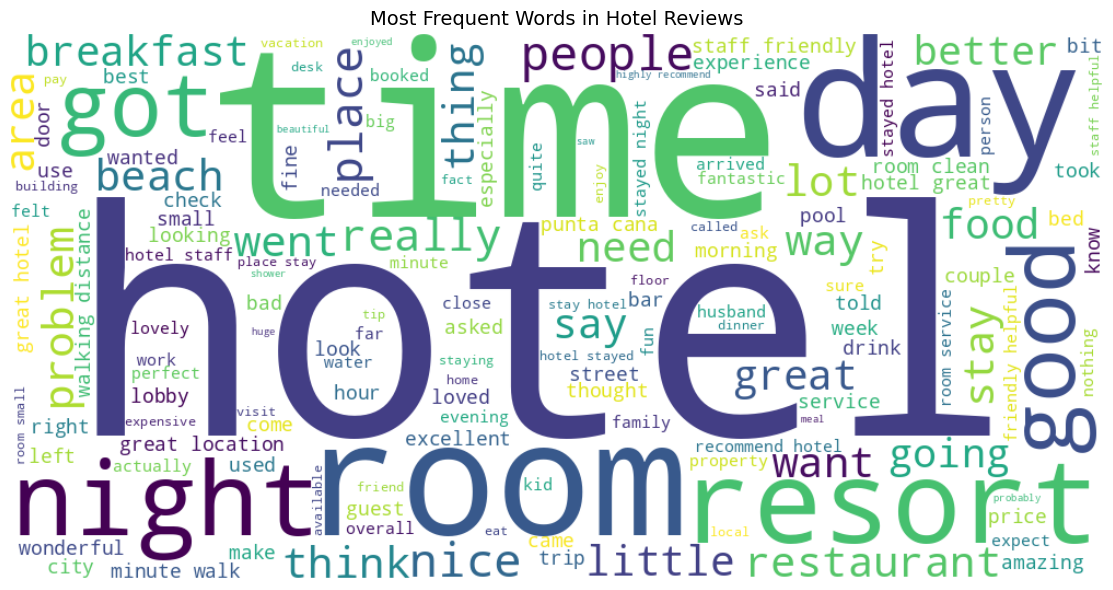

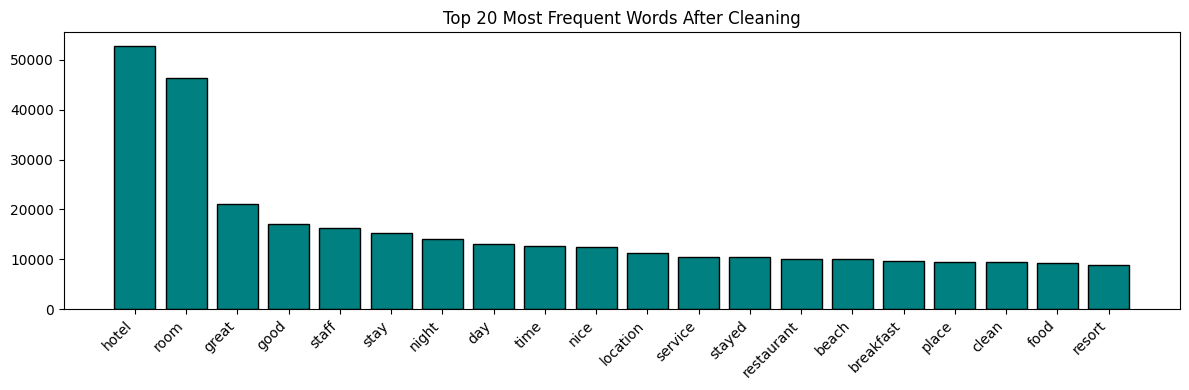

In [8]:
# WordCloud
all_text = ' '.join(df['clean_review'])
wc = WordCloud(width=1000, height=500, background_color='white',
               colormap='viridis', max_words=150).generate(all_text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Hotel Reviews', fontsize=14)
plt.tight_layout(); plt.show()

# Top 20 words bar chart
word_freq = Counter(all_text.split())
top20 = word_freq.most_common(20)
words, counts = zip(*top20)
plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='teal', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words After Cleaning')
plt.tight_layout(); plt.show()

In [9]:
# Labels: Rating 1-5 → 0-4
X = df['clean_review'].values
y = df['Rating'].values - 1 # shift to 0-indexed for sparse_categorical_crossentropy
NUM_CLASSES_NLP = 5

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Tokenize
MAX_WORDS = 15000
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f"Vocab size: {vocab_size}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# 95th percentile padding
lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"MAX_LEN (95th pct): {MAX_LEN}")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f"Train shape: {X_train_pad.shape} | Test shape: {X_test_pad.shape}")

Train: 16392 | Test: 4099
Vocab size: 15000
MAX_LEN (95th pct): 250
Train shape: (16392, 250) | Test shape: (4099, 250)


In [10]:
EMBED_DIM = 64

def build_rnn(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        SimpleRNN(128, return_sequences=True),
        SimpleRNN(64),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='Simple_RNN')
    return model

model1 = build_rnn(vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES_NLP)
model1.summary()

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        ModelCheckpoint(MODEL_SAVE+'model1_rnn_best.h5', save_best_only=True)
    ]
)
rnn_time = time.time() - start
print(f"RNN Training Time: {rnn_time/60:.2f} minutes")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.3823 - loss: 1.4620

231/231 ━━━━━━━━━━━━━━━━━━━━ 63s 252ms/step - accuracy: 0.4075 - loss: 1.4169 - val_accuracy: 0.4457 - val_loss: 1.3646
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 83s 259ms/step - accuracy: 0.4285 - loss: 1.3903 - val_accuracy: 0.4457 - val_loss: 1.3668
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.4419 - loss: 1.3769

231/231 ━━━━━━━━━━━━━━━━━━━━ 80s 251ms/step - accuracy: 0.4366 - loss: 1.3750 - val_accuracy: 0.4457 - val_loss: 1.3570
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.4348 - loss: 1.3723

231/231 ━━━━━━━━━━━━━━━━━━━━ 82s 251ms/step - accuracy: 0.4392 - loss: 1.3690 - val_accuracy: 0.4457 - val_loss: 1.3467
RNN Training Time: 5.14 minutes


In [11]:
def build_lstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len),
        LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        LSTM(64, dropout=0.2),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='LSTM_Model')
    return model

model2 = build_lstm(vocab_size, EMBED_DIM, MAX_LEN, NUM_CLASSES_NLP)
model2.summary()

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        ModelCheckpoint(MODEL_SAVE+'model2_lstm_best.h5', save_best_only=True)
    ]
)
lstm_time = time.time() - start
print(f"LSTM Training Time: {lstm_time/60:.2f} minutes")

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4172 - loss: 1.4106

231/231 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.4301 - loss: 1.3875 - val_accuracy: 0.4457 - val_loss: 1.3530
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4343 - loss: 1.3744

231/231 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.4406 - loss: 1.3650 - val_accuracy: 0.4457 - val_loss: 1.3511
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.4460 - loss: 1.3570 - val_accuracy: 0.4457 - val_loss: 1.3538
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.4467 - loss: 1.3508 - val_accuracy: 0.4402 - val_loss: 1.3752
LSTM Training Time: 18.95 minutes


In [15]:
import gensim.downloader as api

print("Downloading GloVe embeddings (may take a few minutes)...")
embedding_model = api.load('glove-wiki-gigaword-100')
print("Downloaded!")

EMBED_DIM_W2V = 100
word_index = tokenizer.word_index
embedding_matrix = np.zeros((vocab_size, EMBED_DIM_W2V))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1
    else:
        not_found += 1

print(f"Words found in GloVe: {found} | Not found: {not_found}")
print(f"Coverage: {found/(found+not_found)*100:.1f}%")

np.save('/content/drive/MyDrive/6CS012_NLP/models/embedding_matrix.npy', embedding_matrix)
print("Embedding matrix saved to Drive!")

Downloaded!
Words found in GloVe: 12600 | Not found: 2399
Coverage: 84.0%
Embedding matrix saved to Drive!


In [14]:
embedding_matrix = np.load('/content/drive/MyDrive/6CS012_NLP/models/embedding_matrix.npy')

def build_lstm_w2v(vocab_size, embed_matrix, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=100,
                  weights=[embed_matrix], input_length=max_len,
                  trainable=False),           # frozen pretrained weights
        LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
        LSTM(64, dropout=0.2),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='LSTM_Word2Vec')
    return model

model3 = build_lstm_w2v(vocab_size, embedding_matrix, MAX_LEN, NUM_CLASSES_NLP)
model3.summary()

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        ModelCheckpoint(MODEL_SAVE+'model3_lstm_w2v_best.h5', save_best_only=True)
    ]
)
w2v_time = time.time() - start
print(f"LSTM+W2V Training Time: {w2v_time/60:.2f} minutes")

Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,000 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,000 (5.72 MB)

Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4100 - loss: 1.4368

231/231 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.4263 - loss: 1.3965 - val_accuracy: 0.4433 - val_loss: 1.3538
Epoch 2/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.4401 - loss: 1.3708 - val_accuracy: 0.4451 - val_loss: 1.3542
Epoch 3/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4380 - loss: 1.3674

231/231 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.4414 - loss: 1.3663 - val_accuracy: 0.4433 - val_loss: 1.3514
Epoch 4/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.4431 - loss: 1.3626 - val_accuracy: 0.4433 - val_loss: 1.3525
Epoch 5/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4461 - loss: 1.3547

231/231 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.4427 - loss: 1.3626 - val_accuracy: 0.4433 - val_loss: 1.3511
LSTM+W2V Training Time: 23.20 minutes


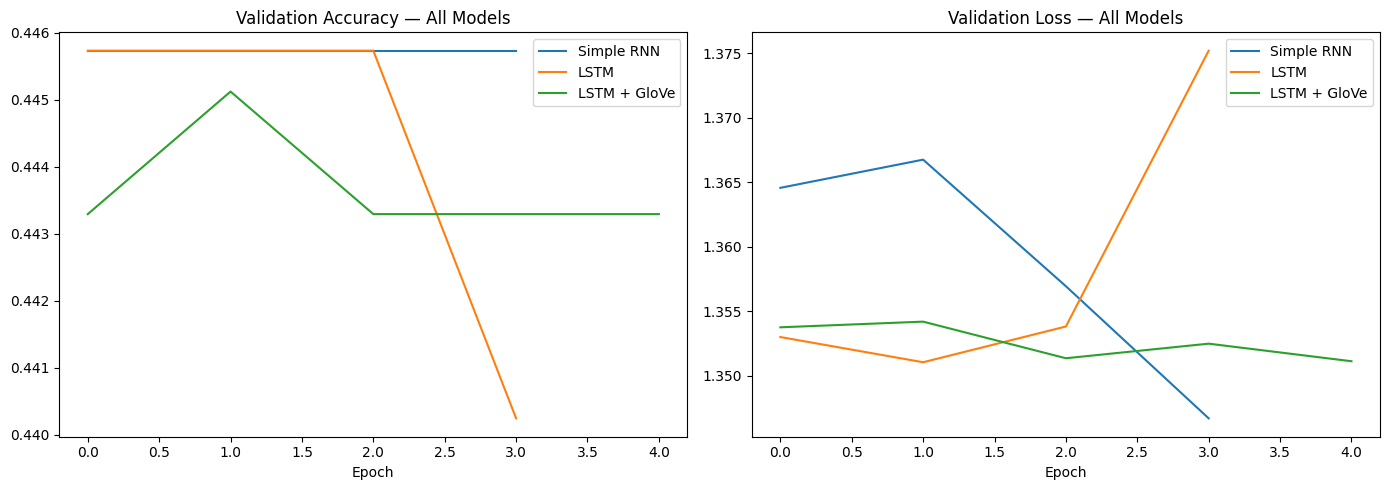

In [16]:
def plot_nlp_history(h1, h2, h3, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for h, name in zip([h1, h2, h3], names):
        axes[0].plot(h.history['val_accuracy'], label=name)
        axes[1].plot(h.history['val_loss'],     label=name)

    axes[0].set_title('Validation Accuracy — All Models')
    axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].set_title('Validation Loss — All Models')
    axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()

plot_nlp_history(history1, history2, history3,
                 ['Simple RNN', 'LSTM', 'LSTM + GloVe'])


Model 1: Simple RNN
Test Loss: 1.3683 | Test Accuracy: 0.4418

Classification Report:
              precision    recall  f1-score   support

      1-Star       0.00      0.00      0.00       284
      2-Star       0.00      0.00      0.00       359
      3-Star       0.00      0.00      0.00       437
      4-Star       0.00      0.00      0.00      1208
      5-Star       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.09      0.20      0.12      4099
weighted avg       0.20      0.44      0.27      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


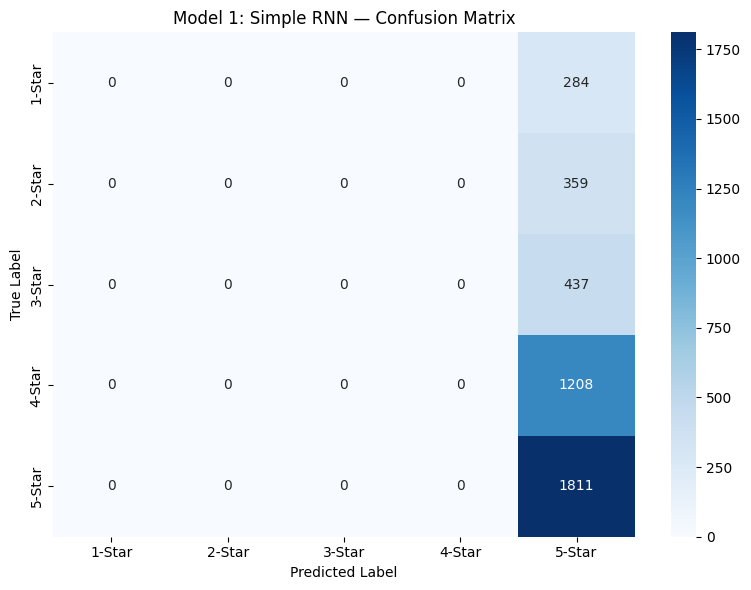


Model 2: LSTM
Test Loss: 1.3584 | Test Accuracy: 0.4418

Classification Report:
              precision    recall  f1-score   support

      1-Star       0.00      0.00      0.00       284
      2-Star       0.00      0.00      0.00       359
      3-Star       0.00      0.00      0.00       437
      4-Star       0.00      0.00      0.00      1208
      5-Star       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.09      0.20      0.12      4099
weighted avg       0.20      0.44      0.27      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


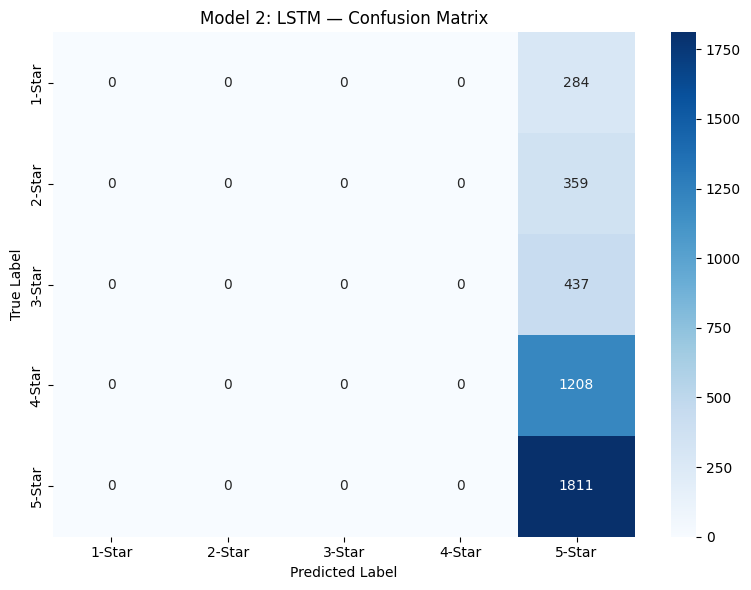


Model 3: LSTM + GloVe
Test Loss: 1.3604 | Test Accuracy: 0.4416

Classification Report:
              precision    recall  f1-score   support

      1-Star       0.00      0.00      0.00       284
      2-Star       0.00      0.00      0.00       359
      3-Star       0.00      0.00      0.00       437
      4-Star       0.00      0.00      0.00      1208
      5-Star       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.09      0.20      0.12      4099
weighted avg       0.20      0.44      0.27      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


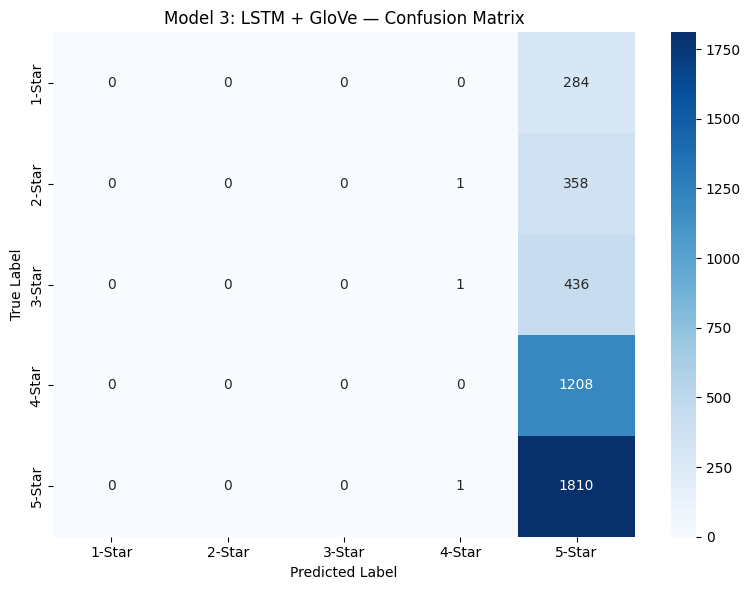

In [17]:
RATING_LABELS = ['1-Star', '2-Star', '3-Star', '4-Star', '5-Star']

def evaluate_nlp(model, X_test, y_test, model_name):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

    preds = model.predict(X_test, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_test, pred_classes, target_names=RATING_LABELS))

    cm = confusion_matrix(y_test, pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=RATING_LABELS, yticklabels=RATING_LABELS)
    plt.title(f'{model_name} — Confusion Matrix')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()
    return acc

acc1 = evaluate_nlp(model1, X_test_pad, y_test, 'Model 1: Simple RNN')
acc2 = evaluate_nlp(model2, X_test_pad, y_test, 'Model 2: LSTM')
acc3 = evaluate_nlp(model3, X_test_pad, y_test, 'Model 3: LSTM + GloVe')

In [18]:
# Analyze misclassified examples from best model (model3)
preds3 = model3.predict(X_test_pad, verbose=0)
pred_classes3 = np.argmax(preds3, axis=1)
wrong_idx = np.where(pred_classes3 != y_test)[0]

print(f"Total misclassified: {len(wrong_idx)} / {len(y_test)} ({len(wrong_idx)/len(y_test)*100:.1f}%)\n")
print("=" * 70)
print("SAMPLE MISCLASSIFIED REVIEWS")
print("=" * 70)

for i in wrong_idx[:3]:
    true_r  = y_test[i] + 1
    pred_r  = pred_classes3[i] + 1
    conf    = np.max(preds3[i]) * 100
    print(f"\nReview: {X_test[i][:200]}...")
    print(f"True Rating: {true_r} | Predicted: {pred_r} | Confidence: {conf:.1f}%")
    print("-" * 70)

# Error by class — which ratings get confused most
print("\nMost Confused Rating Pairs:")
cm = confusion_matrix(y_test, pred_classes3)
for i in range(5):
    for j in range(5):
        if i != j and cm[i][j] > 50:
            print(f"  True:{i+1}-Star → Predicted:{j+1}-Star: {cm[i][j]} times")

Total misclassified: 2289 / 4099 (55.8%)

SAMPLE MISCLASSIFIED REVIEWS

Review: great location nice staff mattress soft night stay early september hotel agora germaine fabulous neighborhood great location near metro stop shop boulangerie food kiosk ethnic food restaurant internet...
True Rating: 3 | Predicted: 5 | Confidence: 47.7%
----------------------------------------------------------------------

Review: nice hotel nice hotel good area explore arrival greated glass bubbly juice arrived early room ready great room road noisy night room quite hot sleep window open extremely noisy bathroom okay water sho...
True Rating: 3 | Predicted: 5 | Confidence: 47.7%
----------------------------------------------------------------------

Review: stayed hotel group friend interesting mixed view experience half group executive room half executive room half problem airconditioning head group rang reception told open window ohthe executive room c...
True Rating: 4 | Predicted: 5 | Confidence: 47.7


FINAL NLP MODEL COMPARISON
Model                          Accuracy   Train Time
-------------------------------------------------------
Simple RNN                       0.4418       5.14m
LSTM                             0.4418      18.95m
LSTM + GloVe Word2Vec            0.4416      23.20m


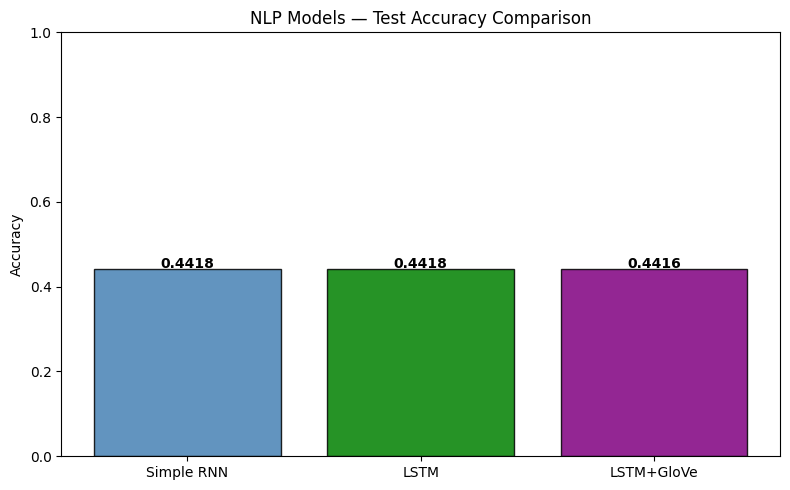

In [19]:
print("\n" + "=" * 55)
print("FINAL NLP MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<28} {'Accuracy':>10} {'Train Time':>12}")
print("-" * 55)
print(f"{'Simple RNN':<28} {acc1:>10.4f} {rnn_time/60:>10.2f}m")
print(f"{'LSTM':<28} {acc2:>10.4f} {lstm_time/60:>10.2f}m")
print(f"{'LSTM + GloVe Word2Vec':<28} {acc3:>10.4f} {w2v_time/60:>10.2f}m")
print("=" * 55)

# Bar chart
models_nlp = ['Simple RNN', 'LSTM', 'LSTM+GloVe']
accs_nlp   = [acc1, acc2, acc3]
colors_nlp = ['steelblue', 'green', 'purple']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_nlp, accs_nlp, color=colors_nlp, edgecolor='black', alpha=0.85)
for bar, acc in zip(bars, accs_nlp):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.ylim(0, 1.0)
plt.title('NLP Models — Test Accuracy Comparison')
plt.ylabel('Accuracy'); plt.tight_layout(); plt.show()

In [20]:
!pip install gradio -q

In [21]:
import gradio as gr

def predict_rating(review_text):
    if not review_text.strip():
        return "Please enter a review."
    cleaned = clean_text(review_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred = model3.predict(padded, verbose=0)
    rating = np.argmax(pred) + 1
    confidence = np.max(pred) * 100
    stars = '⭐' * rating
    return f"{stars} {rating}/5 stars ({confidence:.1f}% confidence)"

demo = gr.Interface(
    fn=predict_rating,
    inputs=gr.Textbox(lines=5, placeholder="Paste a hotel review here...", label="Hotel Review"),
    outputs=gr.Textbox(label="Predicted Rating"),
    title="🏨 Hotel Review Sentiment Classifier",
    description="Predicts hotel rating (1–5 stars) from review text using LSTM + GloVe embeddings."
)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0b00397cfc6e064a65.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
